# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Samuel Sahata Sitompul
- **Email:** cdcc010d6y0317@student.devacademy.id
- **ID Dicoding:** CDCC010D6Y0317

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

Pertanyaan Bisnis

1. ***"Pada jam berapa terjadi lonjakan penyewaan sepeda tertinggi pada hari kerja (working day) dibandingkan dengan akhir pekan selama periode 2011-2012?"***

*  Specific: Fokus pada perbandingan pola penyewaan per jam antara hari kerja dan akhir pekan.
*  Measurable: Diukur menggunakan kolom hr, workingday, dan cnt.
*  Achievable: Dapat dijawab dengan melakukan agregasi rata-rata jumlah penyewaan per jam.
*  Relevant: Penting untuk manajemen operasional dalam mengatur ketersediaan unit sepeda di stasiun tertentu pada jam sibuk.
*  Time-bound: Menggunakan data historis dari tahun 2011 hingga 2012.

2. ***"Bagaimana pengaruh kondisi cuaca (cerah, mendung, hujan) terhadap jumlah total penyewaan sepeda di setiap musimnya?"***
*   Specific: Menentukan hubungan yang jelas antara variabel cuaca (weathersit), musim (season), dan jumlah penyewaan (cnt).
*   Measurable: Data dapat dihitung secara kuantitatif melalui rata-rata atau total penyewaan di setiap kategori cuaca.
*   Achievable: Dataset memiliki kolom lengkap untuk cuaca dan musim sehingga analisis sangat mungkin dilakukan.
*   Relevant: Membantu bisnis memahami risiko penurunan pendapatan akibat cuaca buruk dan merencanakan strategi operasional musiman.
*   Time-bound: Menggunakan data historis dari tahun 2011 hingga 2012.

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [4]:
df = pd.read_csv("hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
*   instant: record index
*   dteday : date
*   season : season (1: spring, 2: summer, 3: fall, 4: winter)
*   yr : year (0: 2011, 1:2012)
*   mnth : month ( 1 to 12)
*   hr : hour (0 to 23)
*   holiday : weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday*  schedule)
*   weekday : day of the week
*   workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
*   weathersit :
    *   1: Clear, Few clouds, Partly cloudy, Partly cloudy
    *   2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    *   3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    *   4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
*   temp : Normalized temperature in Celsius. The values are divided to 41 (max)
*   atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
*   hum: Normalized humidity. The values are divided to 100 (max)
*   windspeed: Normalized wind speed. The values are divided to 67 (max)
*   casual: count of casual users
*   registered: count of registered users
*   cnt: count of total rental bikes including both casual and registered

### Assessing Data

#### Identifying ... problem

In [5]:
df.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


In [6]:
print('Jumlah data duplikasi', df.duplicated().sum())

print('Jumlah data yang hilang', df.isna().sum())

Jumlah data duplikasi 0
Jumlah data yang hilang instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [7]:
print('Jumlah data duplikasi:', df.duplicated().sum())

Jumlah data duplikasi: 0


**Steps to Take:**
- Mengganti object pada fitur dtoday menjadi datetime

**Insight:** (Opsional)
- Data secara keseluruhan tampaknya sudah dinormalisasi, tidak ada outlier (data pencilan) yang berarti tampak pada data, lanjut pada tahap pembersihan data.

### Cleaning Data

#### Fixing ... problem

In [8]:
df['dteday'] = pd.to_datetime(df['dteday'])
print(df.dtypes)

instant                int64
dteday        datetime64[ns]
season                 int64
yr                     int64
mnth                   int64
hr                     int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


**Insight:** (Opsional)
- Sudah dilakukan pembersihan data melalui konversi data

## Exploratory Data Analysis (EDA)

### Explore ...

In [9]:
df.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [10]:
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light Rain', 4: 'Heavy Rain'}

df['season_label'] = df['season'].map(season_map)
df['weather_label'] = df['weathersit'].map(weather_map)

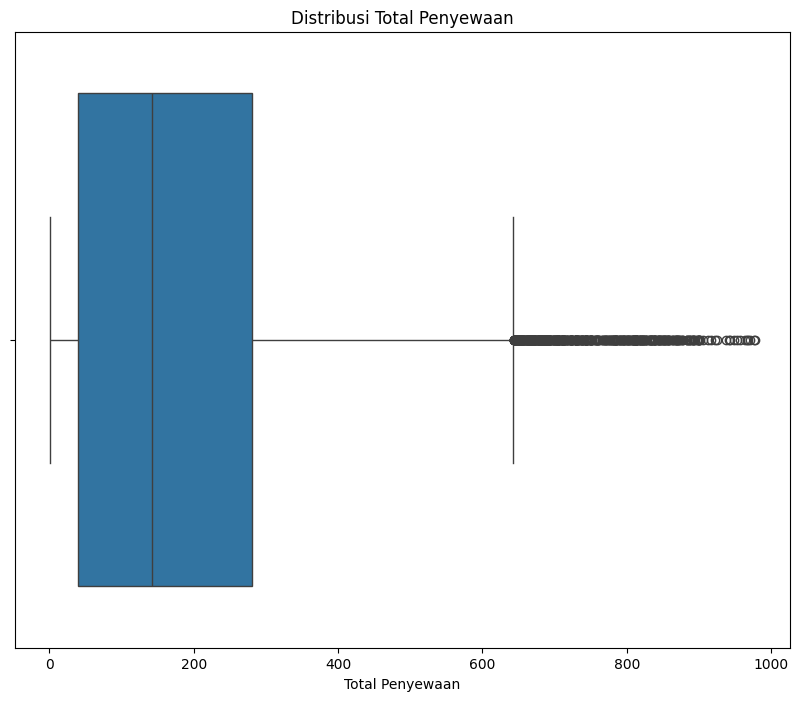

In [11]:
# Mendeteksi outlier, dilakukan untuk mengetahui persebaran data, namun tidak dihapus, karena ini merupakan realitas bisnis saat jam sibuk

plt.figure(figsize=(10, 8))
sns.boxplot(x=df['cnt'])
plt.title('Distribusi Total Penyewaan')
plt.xlabel('Total Penyewaan')
plt.show()

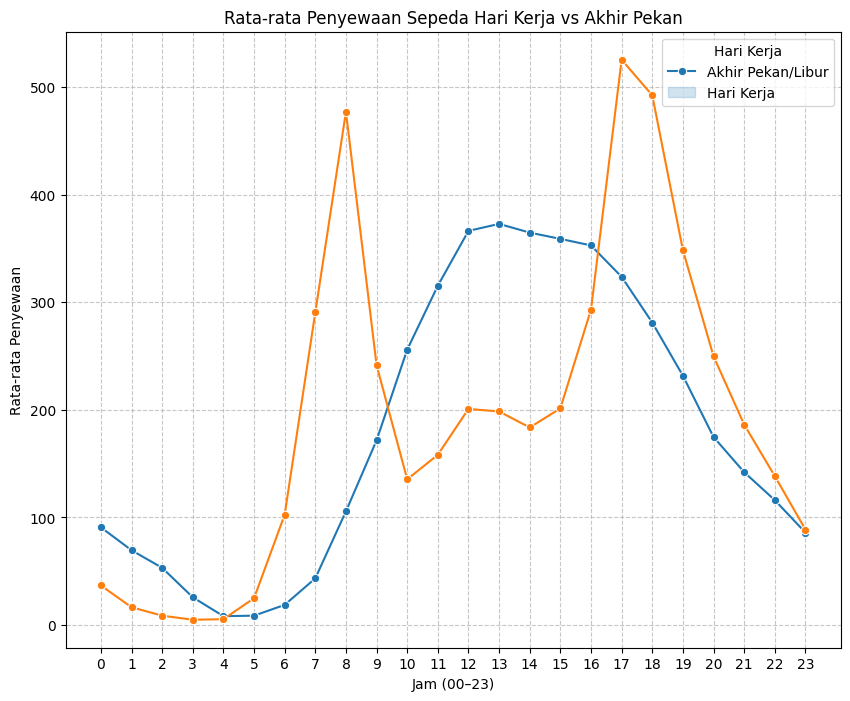

In [12]:
# Menggambarkan lonjakan penyewaan sepeda

peak_hours = df.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()

plt.figure(figsize=(10, 8))
sns.lineplot(data=peak_hours, x='hr', y='cnt', hue='workingday', marker='o')

plt.title('Rata-rata Penyewaan Sepeda Hari Kerja vs Akhir Pekan')
plt.xlabel('Jam (00–23)')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0, 24))
plt.legend(title='Hari Kerja', labels=['Akhir Pekan/Libur', 'Hari Kerja'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

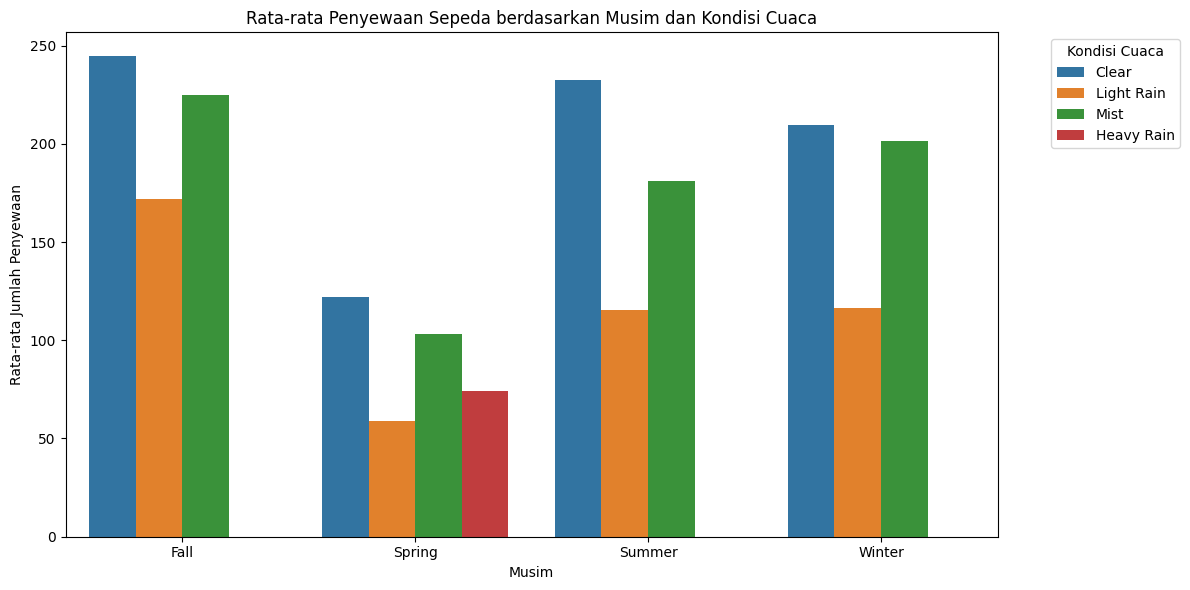

In [13]:
# Grouping data berdasarkan season dan weathersit
weather_season_analysis = df.groupby(['season_label', 'weather_label'])['cnt'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=weather_season_analysis, x='season_label', y='cnt', hue='weather_label')

plt.title('Rata-rata Penyewaan Sepeda berdasarkan Musim dan Kondisi Cuaca')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.legend(title='Kondisi Cuaca', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Dilakukan beberapa visualisasi, ditemukan outlier yang dapat diartikan sebagai *peak hours* dalam hari kerja atau akhir pekan.
- Visualisasi menghitung jumlah penyewaan pada setiap musim ditemukan rata-rata musim semi lebih sedikit secara keseluruhan cuaca.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

In [14]:
# Mencari rata-rata penyewaan per jam untuk hari kerja
rumus_1 = df.groupby(['workingday', 'hr'])['cnt'].mean()
print(rumus_1)

workingday  hr
0           0      90.800000
            1      69.508696
            2      53.171053
            3      25.775330
            4       8.264317
            5       8.689189
            6      18.742358
            7      43.406926
            8     105.653680
            9     171.623377
            10    255.909091
            11    315.316017
            12    366.259740
            13    372.731602
            14    364.645022
            15    358.813853
            16    352.727273
            17    323.549784
            18    281.056522
            19    231.673913
            20    174.739130
            21    142.060870
            22    116.060870
            23     85.930435
1           0      36.786290
            1      16.552632
            2       8.683778
            3       4.942553
            4       5.429787
            5      24.913131
            6     102.500000
            7     290.612903
            8     477.006048
            9     241.518145

In [15]:
max_cnt_workingday_0 = rumus_1.loc[0].max()
hr_max_workingday_0 = rumus_1.loc[0].idxmax()

max_cnt_workingday_1 = rumus_1.loc[1].max()
hr_max_workingday_1 = rumus_1.loc[1].idxmax()

print(f"Penyewa terbanyak saat akhir pekan atau libur adalah {max_cnt_workingday_0:.2f} pada jam ke-{hr_max_workingday_0}")
print(f"Penyewa terbanyak saat untuk hari kerja adalah {max_cnt_workingday_1:.2f} pada jam ke-{hr_max_workingday_1}")

Penyewa terbanyak saat akhir pekan atau libur adalah 372.73 pada jam ke-13
Penyewa terbanyak saat untuk hari kerja adalah 525.29 pada jam ke-17


### Pertanyaan 2:

In [16]:
# Mencari rata-rata penyewaan berdasarkan cuaca di tiap musim
rumus_2 = df.groupby(['season', 'weathersit'])['cnt'].mean()

# Mengambil rata-rata penyewaan untuk kondisi cuaca 'Clear' (weathersit = 1)
mean_clear = rumus_2.loc[(slice(None), 1)].mean()
# Mengambil rata-rata penyewaan untuk kondisi cuaca 'Light Rain' (weathersit = 3)
mean_rain = rumus_2.loc[(slice(None), 3)].mean()

# Menghitung % penurunan secara manual (contoh logika)
penurunan = (mean_clear - mean_rain) / mean_clear * 100

print(f"Rata-rata penyewaan saat cuaca cerah: {mean_clear:.2f}")
print(f"Rata-rata penyewaan saat cuaca hujan ringan: {mean_rain:.2f}")
print(f"Penurunan penyewaan dari cuaca cerah ke hujan ringan: {penurunan:.2f}%")

Rata-rata penyewaan saat cuaca cerah: 202.11
Rata-rata penyewaan saat cuaca hujan ringan: 115.56
Penurunan penyewaan dari cuaca cerah ke hujan ringan: 42.82%


**Insight:** (Opsional)
- Pertanyaan 1 dijawab dengan angka yang dapat menjawab pertanyaan dengan baik
- Pertanyaan 2 pun juga dijawab dengan angka yang dapat menjawab pertanyaan dengan baik
- Dapar diambil kesimpulan berdasarkan hasil tersebut

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Penyewa terbanyak hari kerja adalah saat jam ke-13, dan saat akhir pekan/libur saat jam ke-17
- **Conclusion pertanyaan 2:** Penurunan penyewaan sepeda saat cuaca hujan adalah 42.82%
- Tambahan conclusion pertanyaan 1: Penyewa di hari kerja melonjak di jam ke-6 sampai jam ke-10 dan jam ke-16 sampai jam ke-20, jam ini disebut sebagai *rush hour*. Dan hari libur atau hari pekan jam ke-8 sampai jam ke-23.

**Rekomendasi Action Item:**
- 1. **Manajemen Armada (*Fleet Management*):** Pastikan ketersediaan sepeda maksimal di stasiun-stasiun strategis pada *rush hour* hari kerja (07:00-09:00 dan 16:00-18:00).
- 2. **Pemeliharaan (*Maintenance*):** Jadwalkan *stock opname* dan perbaikan besar armada sepeda pada Musim Semi (Spring) atau saat prediksi cuaca buruk, karena tingkat permintaan sedang berada di titik terendah.
- 3. **Promosi Dinamis:** Berikan insentif berupa diskon penyewaan pada saat cuaca mendung atau saat akhir pekan untuk mendongkrak utilitas aset.